# 09. XGBoost Hyperparameter Tuning
## 반도체 불량 예측 모델 최적화

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

이전 단계에서는 기본 XGBoost에 Decision Threshold Optimization을 적용하여
Fail 검출 성능을 개선하였다.

Base XGBoost는 기본 Threshold 0.5에서 실제 Fail을 검출하지 못했지만,
PR-AUC와 ROC-AUC에서는 Logistic Regression보다 높은 성능을 보였다.

Training Data의 Out-of-Fold 예측 확률을 이용하여
Decision Threshold를 약 0.0086으로 조정한 결과,
최종 Test Data에서 Fail Recall은 47.62%까지 향상되었다.

그러나 본 결과는 XGBoost Hyperparameter를 별도로 최적화하지 않은 상태에서
얻어진 결과이다.

본 Notebook에서는 Training Data 내부의 Cross Validation을 이용하여
XGBoost Hyperparameter를 최적화한다.

### 최적화 원칙

1. Test Data는 Hyperparameter 선택에 사용하지 않는다.
2. 5-Fold Stratified Cross Validation을 사용한다.
3. 주요 모델 선택 기준은 PR-AUC(Average Precision)로 설정한다.
4. 여러 Hyperparameter 조합을 Randomized Search로 탐색한다.
5. 최적 Hyperparameter가 결정된 후 Threshold를 다시 Training Data 내부에서 선택한다.
6. 최종 Test Data에는 확정된 모델과 Threshold를 한 번 적용한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from xgboost import XGBClassifier

set_config(display="text")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. 데이터 준비

기존 모델과 공정하게 비교하기 위해
이전 단계와 동일한 Train/Test Split을 사용한다.

- Test Size: 20%
- `random_state=42`
- `stratify=y`

Hyperparameter Search와 Threshold Selection은
모두 Training Data 내부에서 수행한다.

Test Data는 최종 모델 성능 평가에만 사용한다.

In [2]:
DATA_PATH = Path(
    "../data/processed/uci-secom.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (1567, 592)


In [3]:
feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

X = df[feature_cols].copy()

y = (
    df["Pass/Fail"]
    .replace({
        -1: 0,
        1: 1
    })
    .astype(int)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(
    y.value_counts()
    .sort_index()
)

X shape: (1567, 590)
y shape: (1567,)

Target distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print(
    f"\nTrain Fail Rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Test Fail Rate : "
    f"{y_test.mean() * 100:.2f}%"
)

X_train: (1253, 590)
X_test : (314, 590)

Train Fail Rate: 6.62%
Test Fail Rate : 6.69%


In [5]:
class FeatureQualityFilter(
    BaseEstimator,
    TransformerMixin
):
    def __init__(
        self,
        missing_threshold=40.0
    ):
        self.missing_threshold = (
            missing_threshold
        )

    def fit(self, X, y=None):

        X = pd.DataFrame(X).copy()

        missing_ratio = (
            X.isna()
            .mean()
            .mul(100)
        )

        high_missing = (
            missing_ratio[
                missing_ratio
                >= self.missing_threshold
            ]
            .index
            .tolist()
        )

        all_missing = [
            col for col in X.columns
            if X[col].isna().all()
        ]

        single_value = [
            col for col in X.columns
            if X[col].nunique(
                dropna=True
            ) == 1
        ]

        self.features_to_remove_ = sorted(
            set(
                high_missing
                + all_missing
                + single_value
            )
        )

        self.features_to_keep_ = [
            col for col in X.columns
            if col
            not in self.features_to_remove_
        ]

        self.feature_names_in_ = np.array(
            X.columns,
            dtype=object
        )

        return self

    def transform(self, X):

        X = pd.DataFrame(
            X,
            columns=self.feature_names_in_
        ).copy()

        return X[
            self.features_to_keep_
        ]

    def get_feature_names_out(
        self,
        input_features=None
    ):
        return np.array(
            self.features_to_keep_,
            dtype=object
        )

In [6]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

class_ratio = (
    negative_count
    / positive_count
)

print("Pass samples:", negative_count)
print("Fail samples:", positive_count)

print(
    f"Pass / Fail ratio: "
    f"{class_ratio:.4f}"
)

Pass samples: 1170
Fail samples: 83
Pass / Fail ratio: 14.0964


## 2. Hyperparameter Search 설계

본 단계에서는 Randomized Search를 이용하여
여러 XGBoost Hyperparameter 조합을 탐색한다.

탐색 대상은 다음과 같다.

### `n_estimators`
생성할 Boosting Tree의 수를 조절한다.

### `max_depth`
각 Tree의 최대 깊이를 조절한다.

### `learning_rate`
각 Boosting 단계가 기존 모델을 얼마나 크게 보정할지 결정한다.

### `min_child_weight`
Tree가 세부적으로 분할되는 정도를 제어하는 Regularization 관련 Parameter이다.

### `subsample`
각 Tree 학습에 사용할 Training Sample 비율을 조절한다.

### `colsample_bytree`
각 Tree에서 사용할 Feature 비율을 조절한다.

### `scale_pos_weight`
Fail 클래스에 부여할 상대적인 가중치를 조절한다.

Hyperparameter의 최적 조합은
Training Data의 5-Fold Cross Validation PR-AUC를 기준으로 결정한다.

In [7]:
xgb_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

print(xgb_pipeline)

Pipeline(steps=[('quality_filter', FeatureQualityFilter(missing_threshold=40)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_...None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                  

In [8]:
param_distributions = {
    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10,
        0.20
    ],

    "model__min_child_weight": [
        1,
        3,
        5,
        10
    ],

    "model__subsample": [
        0.6,
        0.8,
        1.0
    ],

    "model__colsample_bytree": [
        0.5,
        0.7,
        0.9,
        1.0
    ],

    "model__scale_pos_weight": [
        1.0,
        3.0,
        5.0,
        8.0,
        10.0,
        round(class_ratio, 4)
    ]
}

In [9]:
tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 3. Randomized Hyperparameter Search

모델 선택 기준은 `average_precision`, 즉 PR-AUC 계열의
Average Precision으로 설정한다.

SECOM 데이터는 Fail 클래스 비율이 매우 낮기 때문에,
전체 Accuracy보다 Fail 클래스의 확률 순위 성능을 우선 개선하는 것이 목적이다.

Randomized Search에서는 40개의 Hyperparameter 조합을 무작위로 선택하고,
각 조합에 대해 5-Fold Cross Validation을 수행한다.

In [10]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,

    n_iter=40,

    scoring="average_precision",

    cv=tuning_cv,

    random_state=42,

    n_jobs=1,

    verbose=1,

    return_train_score=True,

    refit=True,

    error_score="raise"
)

In [11]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,

    n_iter=40,

    scoring="average_precision",

    cv=tuning_cv,

    random_state=42,

    n_jobs=1,

    verbose=1,

    return_train_score=True,

    refit=True,

    error_score="raise"
)

In [12]:
random_search.fit(
    X_train,
    y_train
)

print(
    "Hyperparameter tuning completed."
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Hyperparameter tuning completed.


In [13]:
print(
    f"Best CV PR-AUC: "
    f"{random_search.best_score_:.4f}"
)

Best CV PR-AUC: 0.2111


In [14]:
best_params = (
    random_search.best_params_
)

for parameter, value in best_params.items():
    print(
        f"{parameter}: {value}"
    )

model__subsample: 0.6
model__scale_pos_weight: 3.0
model__n_estimators: 300
model__min_child_weight: 5
model__max_depth: 2
model__learning_rate: 0.03
model__colsample_bytree: 0.9


In [15]:
search_results = pd.DataFrame(
    random_search.cv_results_
)

print(
    "Search candidates:",
    len(search_results)
)

Search candidates: 40


In [16]:
search_summary = search_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",

        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__learning_rate",
        "param_model__min_child_weight",
        "param_model__subsample",
        "param_model__colsample_bytree",
        "param_model__scale_pos_weight"
    ]
].copy()

search_summary = (
    search_summary
    .sort_values(
        "rank_test_score"
    )
    .reset_index(drop=True)
)

search_summary.head(10).round(4)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__min_child_weight,param_model__subsample,param_model__colsample_bytree,param_model__scale_pos_weight
0,1,0.2111,0.0625,0.9997,300,2,0.03,5,0.6,0.9,3.0000
1,2,0.2102,0.0603,1.0000,300,6,0.03,1,1.0,1.0,3.0000
2,3,0.2041,0.0566,1.0000,300,5,0.10,5,1.0,0.9,3.0000
3,4,0.2035,0.0724,1.0000,500,5,0.05,5,0.6,1.0,8.0000
4,5,0.2002,0.0600,0.9999,200,6,0.01,10,0.6,0.9,8.0000
5,6,0.1994,0.0576,1.0000,100,3,0.05,1,0.6,0.9,1.0000
6,7,0.1990,0.0812,1.0000,100,4,0.20,3,0.6,0.5,10.0000
7,8,0.1983,0.0657,1.0000,300,6,0.05,1,0.8,0.7,14.0964
8,9,0.1983,0.0621,1.0000,500,5,0.05,10,1.0,0.9,14.0964
9,10,0.1976,0.0565,0.9999,300,5,0.01,10,0.6,0.7,5.0000


In [17]:
SEARCH_RESULT_PATH = Path(
    "../results/metrics/"
    "xgboost_hyperparameter_search.csv"
)

search_summary.to_csv(
    SEARCH_RESULT_PATH,
    index=False
)

print(
    "Saved to:",
    SEARCH_RESULT_PATH
)

print(
    "File exists:",
    SEARCH_RESULT_PATH.exists()
)

Saved to: ..\results\metrics\xgboost_hyperparameter_search.csv
File exists: True


In [18]:
best_params_df = pd.DataFrame({
    "Parameter":
        list(best_params.keys()),

    "Value":
        list(best_params.values())
})

BEST_PARAMS_PATH = Path(
    "../results/metrics/"
    "xgboost_best_hyperparameters.csv"
)

best_params_df.to_csv(
    BEST_PARAMS_PATH,
    index=False
)

best_params_df

,Parameter,Value
0,model__subsample,0.60
1,model__scale_pos_weight,3.00
2,model__n_estimators,300.00
3,model__min_child_weight,5.00
4,model__max_depth,2.00
5,model__learning_rate,0.03
6,model__colsample_bytree,0.90


## 4. Train / Validation 성능 차이 확인

Hyperparameter Search에서 높은 Training 성능만을 기록하는 모델은
Training Data에 과적합되었을 가능성이 있다.

따라서 상위 후보들의 평균 Training PR-AUC와
평균 Validation PR-AUC를 함께 비교한다.

최종 모델 선택 자체는 Validation PR-AUC를 기준으로 이미 수행되었으며,
Train 성능은 과적합 정도를 이해하기 위한 보조 지표로 사용한다.

In [19]:
best_search_row = (
    search_summary.iloc[0]
)

print(
    f"Best Train PR-AUC: "
    f"{best_search_row['mean_train_score']:.4f}"
)

print(
    f"Best Validation PR-AUC: "
    f"{best_search_row['mean_test_score']:.4f}"
)

print(
    f"Gap: "
    f"{(
        best_search_row['mean_train_score']
        - best_search_row['mean_test_score']
    ):.4f}"
)

Best Train PR-AUC: 0.9997
Best Validation PR-AUC: 0.2111
Gap: 0.7886


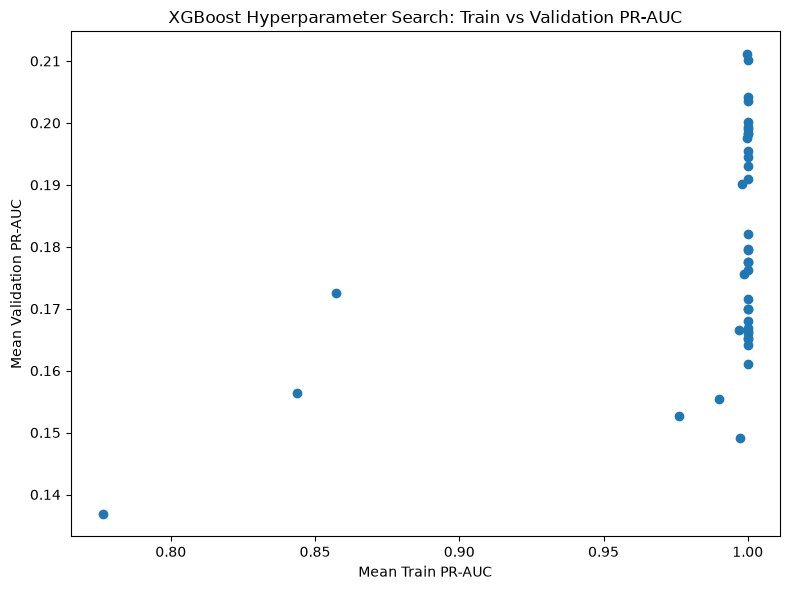

In [20]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    search_summary["mean_train_score"],
    search_summary["mean_test_score"]
)

plt.xlabel(
    "Mean Train PR-AUC"
)

plt.ylabel(
    "Mean Validation PR-AUC"
)

plt.title(
    "XGBoost Hyperparameter Search: "
    "Train vs Validation PR-AUC"
)

plt.tight_layout()

TRAIN_VALIDATION_PATH = Path(
    "../results/figures/"
    "xgboost_train_vs_validation_pr_auc.png"
)

plt.savefig(
    TRAIN_VALIDATION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
best_xgb_pipeline = (
    random_search.best_estimator_
)

print(best_xgb_pipeline)

Pipeline(steps=[('quality_filter', FeatureQualityFilter(missing_threshold=40)),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_t...eights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None, min_child_weig

## 5. Tuned XGBoost의 Decision Threshold 재선택

Hyperparameter Tuning 이후에는 XGBoost의 예측 확률 분포가 달라질 수 있다.

따라서 이전 Base XGBoost에서 선택한 Threshold 0.0086을
Tuned XGBoost에 그대로 적용하지 않는다.

최적 Hyperparameter가 적용된 Pipeline을 이용하여
Training Data에서 새로운 Out-of-Fold 예측 확률을 생성하고,
F2-score를 기준으로 새로운 Decision Threshold를 선택한다.

Threshold Selection에는 Test Data를 사용하지 않는다.

In [22]:
threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2026
)

In [23]:
tuned_oof_probabilities = cross_val_predict(
    best_xgb_pipeline,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=None
)

tuned_oof_fail_prob = (
    tuned_oof_probabilities[:, 1]
)

print(
    "Tuned OOF probabilities:",
    tuned_oof_fail_prob.shape
)

Tuned OOF probabilities: (1253,)


In [24]:
tuned_oof_df = pd.DataFrame({
    "True Label":
        y_train.values,

    "Fail Probability":
        tuned_oof_fail_prob
})

tuned_oof_summary = (
    tuned_oof_df
    .groupby(
        "True Label"
    )[
        "Fail Probability"
    ]
    .agg([
        "count",
        "min",
        "mean",
        "median",
        "max"
    ])
)

tuned_oof_summary

,count,min,mean,median,max
True Label,,,,,
0,1170,0.003488,0.079994,0.051992,0.668798
1,83,0.012086,0.160663,0.117187,0.779901


In [25]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_train,
        tuned_oof_fail_prob
    )
)

precision_at_threshold = (
    precision_values[:-1]
)

recall_at_threshold = (
    recall_values[:-1]
)

beta = 2

f2_values = (
    (1 + beta**2)
    * precision_at_threshold
    * recall_at_threshold
    /
    (
        beta**2
        * precision_at_threshold
        + recall_at_threshold
        + 1e-12
    )
)

tuned_threshold_results = pd.DataFrame({
    "Threshold":
        thresholds,

    "Precision":
        precision_at_threshold,

    "Recall":
        recall_at_threshold,

    "F2":
        f2_values
})

In [26]:
tuned_best_row = (
    tuned_threshold_results
    .sort_values(
        "F2",
        ascending=False
    )
    .iloc[0]
)

tuned_best_threshold = (
    tuned_best_row[
        "Threshold"
    ]
)

print(
    f"Tuned Best Threshold: "
    f"{tuned_best_threshold:.4f}"
)

print(
    f"OOF Precision: "
    f"{tuned_best_row['Precision']:.4f}"
)

print(
    f"OOF Recall: "
    f"{tuned_best_row['Recall']:.4f}"
)

print(
    f"OOF F2: "
    f"{tuned_best_row['F2']:.4f}"
)

Tuned Best Threshold: 0.0742
OOF Precision: 0.1242
OOF Recall: 0.6988
OOF F2: 0.3630


In [27]:
tuned_oof_pred = (
    tuned_oof_fail_prob
    >= tuned_best_threshold
).astype(int)

tuned_oof_cm = confusion_matrix(
    y_train,
    tuned_oof_pred
)

tuned_oof_tn, tuned_oof_fp, \
tuned_oof_fn, tuned_oof_tp = (
    tuned_oof_cm.ravel()
)

print(
    "Tuned OOF Confusion Matrix:"
)

print(tuned_oof_cm)

print(
    "\nFalse Negatives:",
    tuned_oof_fn
)

print(
    "True Positives:",
    tuned_oof_tp
)

print(
    "False Positives:",
    tuned_oof_fp
)

Tuned OOF Confusion Matrix:
[[761 409]
 [ 25  58]]

False Negatives: 25
True Positives: 58
False Positives: 409


In [28]:
TUNED_THRESHOLD_PATH = Path(
    "../results/metrics/"
    "tuned_xgboost_threshold_results.csv"
)

tuned_threshold_results.to_csv(
    TUNED_THRESHOLD_PATH,
    index=False
)

print(
    "Saved to:",
    TUNED_THRESHOLD_PATH
)

Saved to: ..\results\metrics\tuned_xgboost_threshold_results.csv


## 6. 최종 Tuned XGBoost Test 평가

Hyperparameter와 Decision Threshold가
Training Data 내부에서 모두 결정되었다.

이제 최적 Hyperparameter가 적용된 XGBoost를
전체 Training Data에 학습하고,
Test Data에 최종 평가를 수행한다.

Test 결과를 확인한 뒤 Hyperparameter나 Threshold를
다시 변경하지 않는다.

In [30]:
best_xgb_pipeline.fit(
    X_train,
    y_train
)

print(
    "Final tuned XGBoost training completed."
)

Final tuned XGBoost training completed.


In [32]:
tuned_test_prob = (
    best_xgb_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

print(
    "Test probabilities:",
    len(tuned_test_prob)
)

Test probabilities: 314


In [33]:
tuned_test_pred_default = (
    tuned_test_prob >= 0.5
).astype(int)

tuned_default_cm = (
    confusion_matrix(
        y_test,
        tuned_test_pred_default
    )
)

print(
    "Tuned XGBoost @ Threshold 0.5"
)

print(tuned_default_cm)

print(
    f"\nRecall: "
    f"{recall_score(y_test, tuned_test_pred_default):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, tuned_test_pred_default, zero_division=0):.4f}"
)

print(
    f"F2: "
    f"{fbeta_score(y_test, tuned_test_pred_default, beta=2, zero_division=0):.4f}"
)

Tuned XGBoost @ Threshold 0.5
[[292   1]
 [ 21   0]]

Recall: 0.0000
Precision: 0.0000
F2: 0.0000


In [34]:
tuned_test_pred = (
    tuned_test_prob
    >= tuned_best_threshold
).astype(int)

In [35]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_test_pred,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_test_pred,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_pred,
    zero_division=0
)

tuned_f2 = fbeta_score(
    y_test,
    tuned_test_pred,
    beta=2,
    zero_division=0
)

tuned_pr_auc = average_precision_score(
    y_test,
    tuned_test_prob
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_test_prob
)

tuned_cm = confusion_matrix(
    y_test,
    tuned_test_pred
)

print(
    f"Selected Threshold: "
    f"{tuned_best_threshold:.4f}"
)

print(
    f"Accuracy  : "
    f"{tuned_accuracy:.4f}"
)

print(
    f"Precision : "
    f"{tuned_precision:.4f}"
)

print(
    f"Recall    : "
    f"{tuned_recall:.4f}"
)

print(
    f"F1-score  : "
    f"{tuned_f1:.4f}"
)

print(
    f"F2-score  : "
    f"{tuned_f2:.4f}"
)

print(
    f"PR-AUC    : "
    f"{tuned_pr_auc:.4f}"
)

print(
    f"ROC-AUC   : "
    f"{tuned_roc_auc:.4f}"
)

print(
    "\nConfusion Matrix:"
)

print(tuned_cm)

Selected Threshold: 0.0742
Accuracy  : 0.6401
Precision : 0.1102
Recall    : 0.6190
F1-score  : 0.1871
F2-score  : 0.3218
PR-AUC    : 0.1891
ROC-AUC   : 0.6815

Confusion Matrix:
[[188 105]
 [  8  13]]


In [36]:
print(
    classification_report(
        y_test,
        tuned_test_pred,
        target_names=[
            "Pass",
            "Fail"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Pass       0.96      0.64      0.77       293
        Fail       0.11      0.62      0.19        21

    accuracy                           0.64       314
   macro avg       0.53      0.63      0.48       314
weighted avg       0.90      0.64      0.73       314



In [37]:
BASE_THRESHOLD_PATH = Path(
    "../results/metrics/"
    "threshold_test_comparison.csv"
)

base_threshold_results = pd.read_csv(
    BASE_THRESHOLD_PATH
)

base_threshold_results

,Threshold,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives,False Positives
0,0.500000,Base XGBoost (Default Threshold),0.929936,0.000000,0.00000,0.000000,0.000000,0.188125,0.744352,21,0,1
1,0.008612,Base XGBoost (Optimized Threshold),0.821656,0.181818,0.47619,0.263158,0.359712,0.188125,0.744352,11,10,45


In [38]:
tuned_tn, tuned_fp, \
tuned_fn, tuned_tp = (
    tuned_cm.ravel()
)

tuned_result = pd.DataFrame({
    "Threshold": [
        tuned_best_threshold
    ],

    "Model": [
        "Tuned XGBoost "
        "(Optimized Threshold)"
    ],

    "Accuracy": [
        tuned_accuracy
    ],

    "Precision": [
        tuned_precision
    ],

    "Recall": [
        tuned_recall
    ],

    "F1": [
        tuned_f1
    ],

    "F2": [
        tuned_f2
    ],

    "PR-AUC": [
        tuned_pr_auc
    ],

    "ROC-AUC": [
        tuned_roc_auc
    ],

    "False Negatives": [
        tuned_fn
    ],

    "True Positives": [
        tuned_tp
    ],

    "False Positives": [
        tuned_fp
    ]
})

tuned_result.round(4)

,Threshold,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives,False Positives
0,0.0742,Tuned XGBoost (Optimized Threshold),0.6401,0.1102,0.619,0.1871,0.3218,0.1891,0.6815,8,13,105


In [39]:
final_tuning_comparison = pd.concat(
    [
        base_threshold_results,
        tuned_result
    ],
    ignore_index=True
)

final_tuning_comparison.round(4)

,Threshold,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives,False Positives
0,0.5000,Base XGBoost (Default Threshold),0.9299,0.0000,0.0000,0.0000,0.0000,0.1881,0.7444,21,0,1
1,0.0086,Base XGBoost (Optimized Threshold),0.8217,0.1818,0.4762,0.2632,0.3597,0.1881,0.7444,11,10,45
2,0.0742,Tuned XGBoost (Optimized Threshold),0.6401,0.1102,0.6190,0.1871,0.3218,0.1891,0.6815,8,13,105


In [40]:
TUNING_COMPARISON_PATH = Path(
    "../results/metrics/"
    "xgboost_tuning_comparison.csv"
)

final_tuning_comparison.to_csv(
    TUNING_COMPARISON_PATH,
    index=False
)

print(
    "Saved to:",
    TUNING_COMPARISON_PATH
)

Saved to: ..\results\metrics\xgboost_tuning_comparison.csv


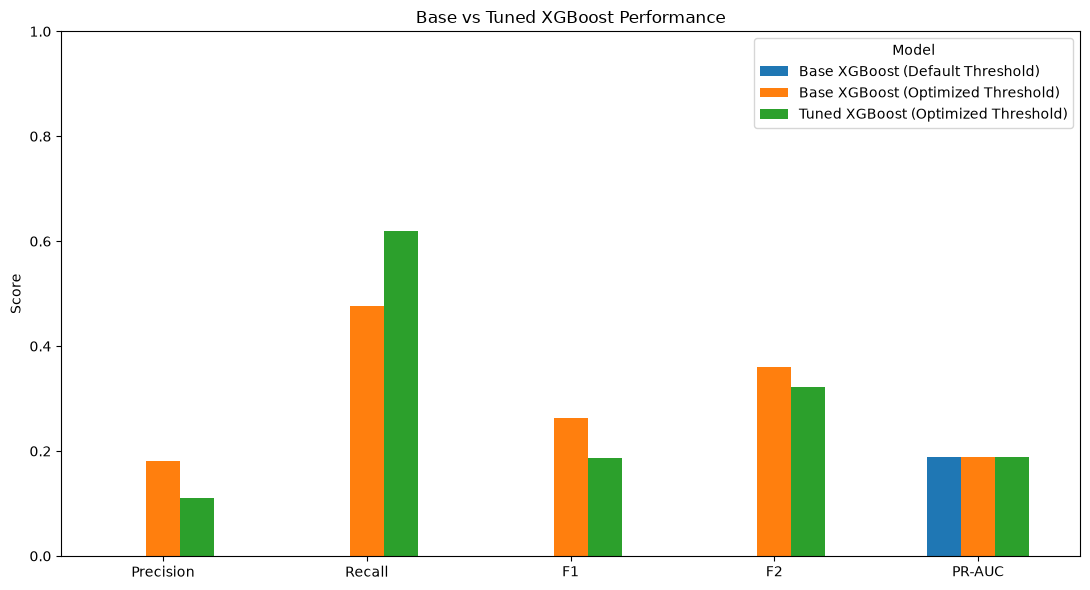

In [41]:
comparison_metrics = [
    "Precision",
    "Recall",
    "F1",
    "F2",
    "PR-AUC"
]

final_tuning_comparison.set_index(
    "Model"
)[
    comparison_metrics
].T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Score")

plt.title(
    "Base vs Tuned XGBoost Performance"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()

TUNING_COMPARISON_FIGURE = Path(
    "../results/figures/"
    "xgboost_tuning_comparison.png"
)

plt.savefig(
    TUNING_COMPARISON_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

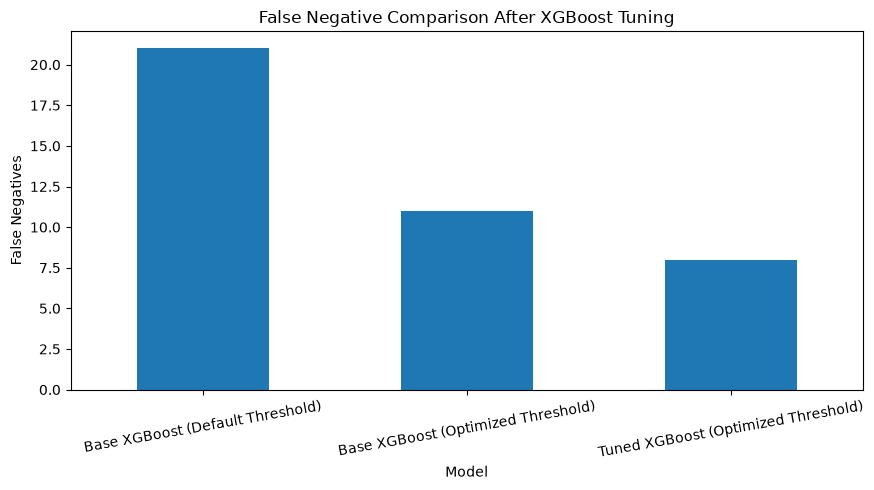

In [42]:
final_tuning_comparison.set_index(
    "Model"
)[
    ["False Negatives"]
].plot(
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.ylabel(
    "False Negatives"
)

plt.title(
    "False Negative Comparison After XGBoost Tuning"
)

plt.xticks(rotation=10)

plt.tight_layout()

TUNING_FN_PATH = Path(
    "../results/figures/"
    "xgboost_tuning_false_negatives.png"
)

plt.savefig(
    TUNING_FN_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

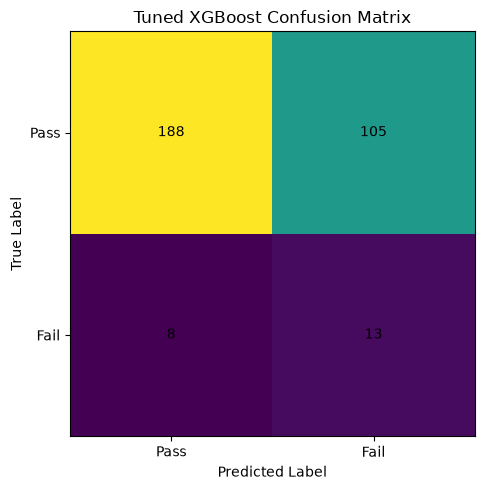

In [43]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    tuned_cm
)

plt.title(
    "Tuned XGBoost Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    ["Pass", "Fail"]
)

plt.yticks(
    [0, 1],
    ["Pass", "Fail"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            tuned_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

TUNED_CM_PATH = Path(
    "../results/figures/"
    "tuned_xgboost_confusion_matrix.png"
)

plt.savefig(
    TUNED_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Hyperparameter Tuning 종합 결과

본 단계에서는 XGBoost 모델의 확률 기반 Fail 구분 성능을 개선하기 위해
Training Data 내부에서 Hyperparameter Tuning을 수행하였다.

Hyperparameter 선택에는 Test Data를 사용하지 않았으며,
5-Fold Stratified Cross Validation의 PR-AUC를 주요 기준으로 사용하였다.


### 1. 최적 Hyperparameter

Randomized Search 결과 다음 조합이 선택되었다.

- `n_estimators`: 300
- `max_depth`: 2
- `learning_rate`: 0.03
- `min_child_weight`: 5
- `subsample`: 0.60
- `colsample_bytree`: 0.90
- `scale_pos_weight`: 3.00

최적 조합의 Cross-Validated PR-AUC는
**0.2111**로 나타났다.

특히 단순 클래스 비율을 기반으로 계산한
`scale_pos_weight=14.0964`가 아니라 3.0이 선택되었다.

이는 클래스 불균형 비율을 그대로 가중치로 사용하는 것이
항상 최적의 결과를 보장하지 않음을 보여준다.


### 2. Tuned XGBoost의 Threshold 재선택

Hyperparameter 변경 이후 예측 확률의 분포가 달라질 수 있기 때문에,
이전 Base XGBoost에서 선택한 Threshold 0.0086을 재사용하지 않았다.

Tuned XGBoost의 Out-of-Fold 예측 확률을 새로 생성하고
F2-score를 기준으로 Decision Threshold를 다시 탐색하였다.

선택된 Threshold는:

**0.0742**

였다.

해당 Threshold에서 Training OOF 성능은:

- Precision: 12.42%
- Recall: 69.88%
- F2-score: 36.30%

로 나타났다.

OOF Confusion Matrix는:

- True Negative: 761개
- False Positive: 409개
- False Negative: 25개
- True Positive: 58개

였다.

실제 Training Fail 83개 중 58개를
Out-of-Fold 환경에서 검출하였다.


### 3. 최종 Test 성능

Training Data에서 확정한 Hyperparameter와 Threshold를
Test Data에 적용한 결과는 다음과 같다.

- Accuracy: **64.01%**
- Precision: **11.02%**
- Recall: **61.90%**
- F1-score: **18.71%**
- F2-score: **32.18%**
- PR-AUC: **0.1891**
- ROC-AUC: **0.6815**

Confusion Matrix는 다음과 같다.

- True Negative: 188개
- False Positive: 105개
- False Negative: 8개
- True Positive: 13개

실제 Fail 21개 중 13개를 검출하였으며,
8개의 Fail을 Pass로 잘못 판단하였다.

Hyperparameter Search에서 선택된 모델의 평균 Cross-Validated PR-AUC는
0.2111이었으나, 최종 고정 Test split에서의 PR-AUC는 0.1891로 나타났다.

따라서 Training Cross Validation에서 확인된 성능 향상이
최종 평가 데이터에서 동일한 수준으로 재현되지는 않았다.

이는 Fail 샘플 수가 제한적인 불균형 데이터의 특성상
데이터 분할에 따른 성능 변동성이 존재할 가능성을 시사한다.
따라서 다음 단계에서는 단일 Holdout 결과뿐만 아니라
반복 Cross Validation을 이용한 모델 안정성도 함께 확인한다.

### 4. Base XGBoost + Threshold와 비교

이전 Base XGBoost에 Threshold Optimization을 적용한 결과는:

- Precision: 18.18%
- Recall: 47.62%
- F2-score: 35.97%
- PR-AUC: 0.1881
- ROC-AUC: 0.7444
- False Negative: 11개
- True Positive: 10개
- False Positive: 45개

였다.

Tuned XGBoost에서는:

- Precision: 11.02%
- Recall: 61.90%
- F2-score: 32.18%
- PR-AUC: 0.1891
- ROC-AUC: 0.6815
- False Negative: 8개
- True Positive: 13개
- False Positive: 105개

로 나타났다.

Hyperparameter Tuning 후 Fail Recall은
47.62%에서 61.90%로 향상되었으며,
False Negative는 11개에서 8개로 감소하였다.

즉 기존 모델보다 3개의 Fail 샘플을 추가적으로 검출하였다.


### 5. 성능 향상의 Trade-off

Fail 검출 능력이 향상된 대신
False Positive가 45개에서 105개로 크게 증가하였다.

이에 따라:

- Precision은 18.18%에서 11.02%로 감소
- F2-score는 35.97%에서 32.18%로 감소
- Accuracy는 82.17%에서 64.01%로 감소

하였다.

또한 Test PR-AUC는 0.1881에서 0.1891로
매우 제한적인 수준의 변화만 나타났으며,
ROC-AUC는 0.7444에서 0.6815로 감소하였다.

따라서 Hyperparameter Tuning이 모델의 모든 평가 지표를
일관되게 개선했다고 판단할 수는 없다.


### 6. 결과 해석

Tuned XGBoost는 현재까지 가장 높은 Fail Recall과
가장 적은 False Negative를 기록하였다.

그러나 이 결과는 정상 샘플을 Fail로 판단하는
False Positive의 큰 증가를 대가로 얻은 것이다.

따라서 최종 모델 선정 시에는
Fail Recall 하나만을 기준으로 판단하지 않고,

- False Negative
- False Positive
- Precision
- F2-score
- PR-AUC

를 함께 고려해야 한다.

특히 실제 반도체 제조 환경에서는
Fail 제품을 놓치는 비용과 정상 제품을 재검사하거나
Fail로 판단하는 비용이 서로 다르기 때문에,
두 오류의 상대적인 비용을 고려한 운영 기준이 필요하다.


## 다음 단계: 전체 모델 종합 평가

다음 단계에서는 지금까지 구축한 모델을 하나의 기준으로 비교한다.

비교 대상은 다음과 같다.

1. Dummy Classifier
2. Logistic Regression
3. Logistic Regression + SMOTE 1:1
4. Base XGBoost
5. Base XGBoost + Optimized Threshold
6. Tuned XGBoost + Optimized Threshold

각 모델의 다음 지표를 종합적으로 비교한다.

- Accuracy
- Precision
- Recall
- F1-score
- F2-score
- PR-AUC
- ROC-AUC
- False Negative
- False Positive
- True Positive

최종적으로 단일 지표만으로 Best Model을 선정하기보다,
Fail 검출 성능과 오탐 비용 사이의 Trade-off를 고려하여
최종 모델 후보를 선정한다.